# Level 1 Binary PS or not PS ResNet50

**Task**: Binary classification - PS vs No PS
**Model**: ResNet50
**Platform**: Kaggle (GPU T4)
**Hyperparameters**: Pre-filled from Optuna search

---

## Notebook Structure

1. Enviroment setup
2. Configuration - all hyperparameters in one place
3. Dataset & stratified split (70 / 20 / 10)
4. Class distribution analysis
5. Model, loss, optimizer, early stopping
6. Training loop (with validation + early stopping per epoch)
7. Training curve analysis
8. Evaluation - confusion matrix (raw + normalised)
9. Evaluation - full classification report
10. Evaluation - ROC curve with AUC with Youden threshold
11. Evaluation - threshold sensitivity analysis
12. Qualitative inference - test set sample grid
13. Model export & summary

## 1. Environment Setup

In [1]:
!pip install -q accelerate albumentations

In [2]:
import os, gc, random, torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker 
import seaborn as sns
import albumentations as A
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from albumentations.pytorch import ToTensorV2
from accelerate import Accelerator
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("Environment ready.")
print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

Environment ready.
PyTorch 2.9.0+cu126 | CUDA available: True


## 2. Configuration


In [3]:
# Paths 
ROOT_DIR = "/kaggle/input/datasets/cezarytubacki/pressure-ulcers-binary-classification/PSDCB"
OUTPUT_DIR = "/kaggle/working"

# Image
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Split 
TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

# Optuna best params 
MODEL_NAME = "ResNet50"
HEAD_TYPE = "mlp"
DROPOUT = 0.5840440590860216
LR = 9.8967421793598e-05
WEIGHT_DECAY = 0.00014875036515506475
BATCH_SIZE = 16
GRADIENT_ACCUMULATION = 1
NUM_EPOCHS = 50 # raised ceiling — early stopping will cut this short
SCHEDULER_NAME  = "CosineAnnealingLR"
UNFREEZE_EPOCH_STAGE1 = 3
UNFREEZE_EPOCH_STAGE2 = 7

# Early stopping
# Monitors val_loss. Stops when it hasn't improved for PATIENCE epochs.
# DELTA = minimum improvement required to count as 'better' (avoids micro-fluctuations).
ES_PATIENCE = 8
ES_DELTA = 1e-4

# Scheduler params
SCHEDULER_PARAMS = {
    "ExponentialLR": {"gamma": None},
    "StepLR": {"step_size": None, "gamma": None},
    "CosineAnnealingLR": {"T_max": NUM_EPOCHS},
    "ReduceLROnPlateau": {"mode": "min", "patience": 3},
}[SCHEDULER_NAME]

# ── Binary classification threshold ─────────────────────────
# Updated automatically after ROC analysis (Youden's J)
BINARY_THRESHOLD = 0.5

print(f"Model : {MODEL_NAME}")
print(f"Head : {HEAD_TYPE} | Dropout: {DROPOUT:.4f}")
print(f"LR : {LR:.2e} | Weight decay: {WEIGHT_DECAY:.2e}")
print(f"Batch size : {BATCH_SIZE} | Max epochs: {NUM_EPOCHS}")
print(f"Scheduler : {SCHEDULER_NAME}")
print(f"Early stopping: patience={ES_PATIENCE}, delta={ES_DELTA}")
print(f"Unfreeze : stage1 @ epoch {UNFREEZE_EPOCH_STAGE1}, stage2 @ epoch {UNFREEZE_EPOCH_STAGE2}")

Model : ResNet50
Head : mlp | Dropout: 0.5840
LR : 9.90e-05 | Weight decay: 1.49e-04
Batch size : 16 | Max epochs: 50
Scheduler : CosineAnnealingLR
Early stopping: patience=8, delta=0.0001
Unfreeze : stage1 @ epoch 3, stage2 @ epoch 7


## 3. Dataset Classes & Stratified Split

Stratified 70 / 20 / 10 split - class ratios are preserved in each partition. 
The test set is held out completely and never used during training or early stopping.

In [4]:
class PressureSoreDataset(Dataset):
    """Loads images from class subfolders. Returns raw PIL Images."""
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = []

        for i, name in enumerate(sorted(os.listdir(root_dir))):
            if os.path.isdir(os.path.join(root_dir, name)):
                self.class_to_idx[name] = i
                self.idx_to_class.append(name)

        for name in sorted(os.listdir(root_dir)):
            label_dir = os.path.join(root_dir, name)
            if not os.path.isdir(label_dir):
                continue
            for fname in os.listdir(label_dir):
                fpath = os.path.join(label_dir, fname)
                if fpath.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    self.image_paths.append(fpath)
                    self.labels.append(self.class_to_idx[name])

        print(f"Found {len(self.image_paths)} images in {len(self.class_to_idx)} classes.")
        print(f"Class mapping: {self.class_to_idx}")

    def __len__(self):  return len(self.image_paths)
    def __getitem__(self, idx):
        return Image.open(self.image_paths[idx]).convert("RGB"), self.labels[idx]


class TransformedDataset(Dataset):
    """Wraps a Subset and applies an Albumentations transform."""
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):  return len(self.base_dataset)
    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        if self.transform:
            if isinstance(self.transform, A.core.composition.BaseCompose):
                image = self.transform(image=np.array(image))["image"]
            else:
                image = self.transform(image)
        return image, label

# Load 
full_dataset = PressureSoreDataset(ROOT_DIR)
all_labels = full_dataset.labels
class_names = full_dataset.idx_to_class
n_classes = len(class_names)

# Stratified split
indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(
    indices, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=all_labels, random_state=SEED
)
temp_labels   = [all_labels[i] for i in temp_idx]
relative_test = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=relative_test,
    stratify=temp_labels, random_state=SEED
)

print(f"\nStratified split (seed={SEED}):")
for split_name, idx_list in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    split_labels = [all_labels[i] for i in idx_list]
    counts = {c: split_labels.count(v) for c, v in full_dataset.class_to_idx.items()}
    print(f"  {split_name:6s}: {len(idx_list):4d} images | {counts}")

Found 2602 images in 2 classes.
Class mapping: {'not pressure sore': 0, 'pressure sore': 1}

Stratified split (seed=42):
  Train : 1821 images | {'not pressure sore': 910, 'pressure sore': 911}
  Val   :  520 images | {'not pressure sore': 260, 'pressure sore': 260}
  Test  :  261 images | {'not pressure sore': 131, 'pressure sore': 130}


## 4. Class Distribution Analysis

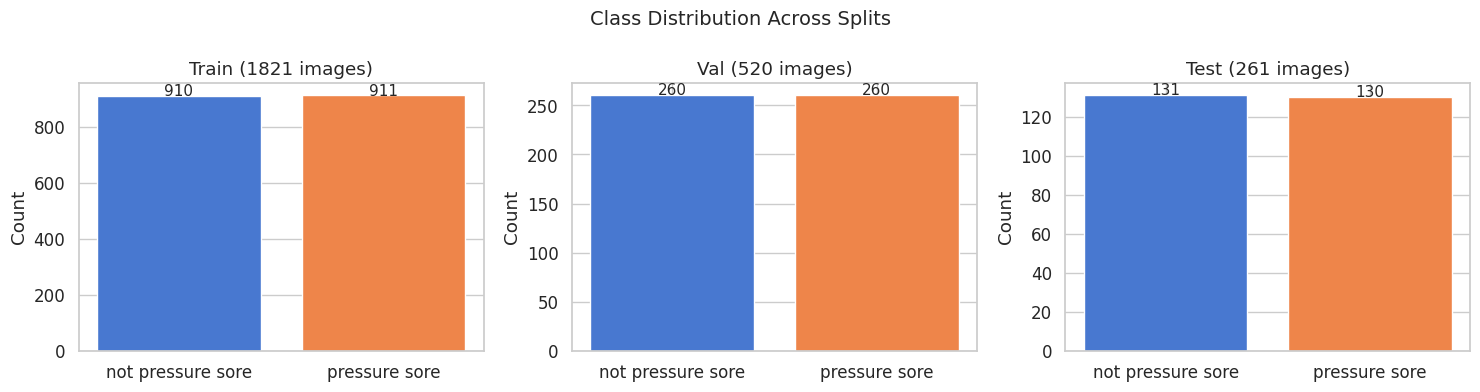

Train imbalance ratio: 1.00


In [5]:
split_data = {
    "Train" : [all_labels[i] for i in train_idx],
    "Val" : [all_labels[i] for i in val_idx],
    "Test" : [all_labels[i] for i in test_idx],
}

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (split_name, lbls) in zip(axes, split_data.items()):
    counts = [lbls.count(v) for v in range(n_classes)]
    bars = ax.bar(class_names, counts, color=sns.color_palette("muted", n_classes))
    ax.set_title(f"{split_name} ({len(lbls)} images)")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha="center", fontsize=11)

plt.suptitle("Class Distribution Across Splits", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

train_counts = [split_data["Train"].count(v) for v in range(n_classes)]
ratio = max(train_counts) / min(train_counts)
flag = " ⚠️ consider class weights" if ratio > 2.0 else ""
print(f"Train imbalance ratio: {ratio:.2f}{flag}")

## 5. Model, Loss, Optimizer & Early Stopping

**Early stopping logic**: monitors `val_loss` after every epoch. If it has not improved by at least `ES_DELTA` for `ES_PATIENCE` consecutive epochs, training halts and the best checkpoint is automatically restored.

Why `val_loss` and not `val_acc`? Loss is a continuous signal - accuracy jumps in discrete steps and can plateau artificially at the same value for many epochs while the model is still improving or degrading underneath.

In [6]:
# Transforms
train_transforms = A.Compose([
    A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5, border_mode=0),
    A.ColorJitter(brightness=0.1, contrast=0.1, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

train_ds = TransformedDataset(Subset(full_dataset, train_idx), train_transforms)
val_ds = TransformedDataset(Subset(full_dataset, val_idx), val_test_transforms)
test_ds = TransformedDataset(Subset(full_dataset, test_idx), val_test_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=os.cpu_count(), pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=os.cpu_count(), pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=os.cpu_count(), pin_memory=True)

print(f"Batches - train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Batches - train: 114 | val: 33 | test: 17


In [7]:
# Model builder
def build_model(model_name, num_classes=1, dropout=0.5, head_type="linear"):
    weights_map = {
        "EfficientNet_B0": models.EfficientNet_B0_Weights.IMAGENET1K_V1,
        "EfficientNet_B1": models.EfficientNet_B1_Weights.IMAGENET1K_V2,
        "EfficientNet_B4": models.EfficientNet_B4_Weights.IMAGENET1K_V1,
        "ViT_B_16": models.ViT_B_16_Weights.IMAGENET1K_V1,
        "MaxVit_T": models.MaxVit_T_Weights.IMAGENET1K_V1,
        "Wide_ResNet50_2": models.Wide_ResNet50_2_Weights.IMAGENET1K_V2,
        "ResNet50": models.ResNet50_Weights.IMAGENET1K_V2,
        "ResNet152": models.ResNet152_Weights.IMAGENET1K_V2,
        "Swin_V2_S": models.Swin_V2_S_Weights.IMAGENET1K_V1,
        "Swin_V2_T": models.Swin_V2_T_Weights.IMAGENET1K_V1,
        "ConvNeXt_Tiny": models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1,
    }
    model_fn_map = {
        "EfficientNet_B0": models.efficientnet_b0,
        "EfficientNet_B1": models.efficientnet_b1,
        "EfficientNet_B4": models.efficientnet_b4,
        "ViT_B_16": models.vit_b_16,
        "MaxVit_T": models.maxvit_t,
        "Wide_ResNet50_2": models.wide_resnet50_2,
        "ResNet50": models.resnet50,
        "ResNet152": models.resnet152,
        "Swin_V2_S": models.swin_v2_s,
        "Swin_V2_T": models.swin_v2_t,
        "ConvNeXt_Tiny": models.convnext_tiny,
    }
    base = model_fn_map[model_name](weights=weights_map[model_name])

    if model_name.startswith("ViT"):
        in_features = base.heads.head.in_features
    elif model_name.startswith("MaxVit") or model_name.startswith("Conv"):
        in_features = base.classifier[-1].in_features
    elif model_name.startswith("Swin"):
        in_features = base.head.in_features
    elif hasattr(base, "fc"):
        in_features = base.fc.in_features
    else:
        in_features = base.classifier[1].in_features

    if head_type == "linear":
        head = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))
    else:  # mlp
        head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, in_features // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(in_features // 2, num_classes),
        )

    if model_name.startswith("ViT"):
        base.heads.head = head
    elif model_name.startswith("MaxVit") or model_name.startswith("Conv"):
        base.classifier[-1] = head
    elif model_name.startswith("Swin"):
        base.head = head
    elif hasattr(base, "fc"):
        base.fc = head
    else:
        base.classifier = head
    return base


#  Scheduler builder
def build_scheduler(name, optimizer, num_epochs=None, params=None):
    params = params or {}
    if name == "CosineAnnealingLR":
        if "T_max" not in params and num_epochs:
            params["T_max"] = num_epochs
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, **params)
    elif name == "StepLR":
        return optim.lr_scheduler.StepLR(optimizer, **params)
    elif name == "ExponentialLR":
        return optim.lr_scheduler.ExponentialLR(optimizer, **params)
    elif name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, **params)
    raise ValueError(f"Unknown scheduler: {name}")


# Freeze helpers 
def set_requires_grad(model, flag):
    for p in model.parameters(): p.requires_grad = flag

def freeze_backbone_except_head(model, model_name):
    set_requires_grad(model, False)
    if model_name.startswith("ViT"):
        for p in model.heads.head.parameters():     p.requires_grad = True
    elif model_name.startswith("MaxVit") or model_name.startswith("Conv"):
        for p in model.classifier[-1].parameters(): p.requires_grad = True
    elif model_name.startswith("Swin"):
        for p in model.head.parameters():           p.requires_grad = True
    elif hasattr(model, "fc"):
        for p in model.fc.parameters():             p.requires_grad = True
    else:
        for p in model.classifier.parameters():     p.requires_grad = True

def unfreeze_stage(model, model_name, stage):
    if model_name.startswith("Wide_ResNet") or model_name.startswith("ResNet"):
        if stage == 1:
            print(f"  Unfreezing {model_name}: layer4")
            for p in model.layer4.parameters(): p.requires_grad = True
        else:
            print(f"  Unfreezing {model_name}: full backbone")
            set_requires_grad(model, True)
    elif model_name.startswith("ViT"):
        if stage == 1:
            print("  Unfreezing ViT: last 4 encoder layers")
            n = len(model.encoder.layers)
            for i in range(max(0, n - 4), n):
                for p in model.encoder.layers[i].parameters(): p.requires_grad = True
        else:
            print("  Unfreezing ViT: full backbone")
            set_requires_grad(model, True)
    elif model_name.startswith("MaxVit"):
        if stage == 1:
            print("  Unfreezing MaxViT: last block")
            for p in model.blocks[-1].parameters(): p.requires_grad = True
        else:
            print("  Unfreezing MaxViT: full backbone")
            set_requires_grad(model, True)
    else:  # Swin, ConvNeXt, EfficientNet
        if stage == 1:
            print(f"  Unfreezing {model_name}: last features block")
            for p in model.features[-1].parameters(): p.requires_grad = True
        else:
            print(f"  Unfreezing {model_name}: full backbone")
            set_requires_grad(model, True)

# Early Stopping
class EarlyStopping:
    def __init__(self, patience: int = 8, delta: float = 1e-4, path: str = "checkpoint.pth", verbose: bool = True):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.verbose = verbose
        self.counter = 0 # epochs without improvement
        self.best_loss = float("inf")
        self.early_stop = False

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        """
        Returns True if a new best was found (checkpoint saved), False otherwise.
        Set self.early_stop = True when patience is exhausted.
        """
        improved = val_loss < (self.best_loss - self.delta)

        if improved:
            if self.verbose:
                print(f"✅ val_loss improved {self.best_loss:.4f} -> {val_loss:.4f} (saved checkpoint)")
                self.best_loss = val_loss
                self.counter = 0
                torch.save(model.state_dict(), self.path)
                return True
        else:
            self.counter += 1
            if self.verbose:
                print(f"No improvement for {self.counter}/{self.patience} epochs (best={self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.early_stop = True
                print(f"🛑 Early stopping triggered after {self.patience} epochs without improvement.")
            return False
    
    @property
    def best_epoch_loss(self) -> float:
        return self.best_loss

print("All helpers defined.")

All helpers defined.


## 6. Training Loop 

* Validation runs at the end of every epoch
* `EarlyStopping` saves the best checkpoint and halts training when `val_loss` stalls


In [8]:
accelerator = Accelerator(mixed_precision="fp16")
device = accelerator.device

BEST_WEIGHTS_PATH = f"{OUTPUT_DIR}/best_{MODEL_NAME}_{HEAD_TYPE}_{SCHEDULER_NAME}.pth"

model = build_model(MODEL_NAME, num_classes=1, dropout=DROPOUT, head_type=HEAD_TYPE)
loss_fn = nn.BCEWithLogitsLoss()
early_stopping = EarlyStopping(
    patience=ES_PATIENCE,
    delta=ES_DELTA,
    path=BEST_WEIGHTS_PATH,
    verbose=True,
)

freeze_backbone_except_head(model, MODEL_NAME)
trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.AdamW(trainable, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)

model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
    model, optimizer, train_loader, val_loader, scheduler
)

history = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"Training on {device} - {MODEL_NAME} | {HEAD_TYPE} head")
print(f"Backbone frozen — only classification head is trainable.\n")

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print("─" * 45)

    # Gradual unfreezing
    unwrapped = accelerator.unwrap_model(model)
    if epoch + 1 == UNFREEZE_EPOCH_STAGE1:
        unfreeze_stage(unwrapped, MODEL_NAME, stage=1)
        # Re-init optimizer + scheduler with newly trainable params
        trainable = filter(lambda p: p.requires_grad, unwrapped.parameters())
        optimizer = optim.AdamW(trainable, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)
        model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
            unwrapped, optimizer, train_loader, val_loader, scheduler
        )
        # Reset early stopping counter — the model just changed structure
        early_stopping.counter = 0
        print("  Early stopping counter reset after unfreezing.")

    elif epoch + 1 == UNFREEZE_EPOCH_STAGE2:
        unfreeze_stage(unwrapped, MODEL_NAME, stage=2)
        trainable = filter(lambda p: p.requires_grad, unwrapped.parameters())
        optimizer = optim.AdamW(trainable, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)
        model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
            unwrapped, optimizer, train_loader, val_loader, scheduler
        )
        early_stopping.counter = 0
        print("  Early stopping counter reset after unfreezing.")

    # Train phase
    model.train()
    train_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc="  Train", leave=False):
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        with accelerator.accumulate(model):
            optimizer.zero_grad()
            loss = loss_fn(model(inputs), labels)
            accelerator.backward(loss)
            optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="  Val  ", leave=False):
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(inputs)
            val_loss += loss_fn(outputs, labels).item()
            preds = (torch.sigmoid(outputs) >= BINARY_THRESHOLD).float()
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = val_correct / val_total

    # Scheduler step
    if SCHEDULER_NAME == "ReduceLROnPlateau":
        scheduler.step(avg_val_loss)
    else:
        scheduler.step()

    # Record 
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"  train_loss={avg_train_loss:.4f}  val_loss={avg_val_loss:.4f}  val_acc={val_acc:.4f}")

    # Early stopping check 
    # Pass the unwrapped model so the saved .pth is plain state_dict
    early_stopping(avg_val_loss, accelerator.unwrap_model(model))
    if early_stopping.early_stop:
        print(f"\nStopped at epoch {epoch+1}. Best val_loss: {early_stopping.best_epoch_loss:.4f}")
        break

    print()

# Restore best weights for evaluation 
print("\nRestoring best checkpoint for evaluation...")
accelerator.unwrap_model(model).load_state_dict(
    torch.load(BEST_WEIGHTS_PATH, map_location=device)
)
print(f"Best weights loaded from: {BEST_WEIGHTS_PATH}")
print(f"Epochs run: {len(history['train_loss'])} / {NUM_EPOCHS}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s] 


Training on cuda - ResNet50 | mlp head
Backbone frozen — only classification head is trainable.

Epoch 1/50
─────────────────────────────────────────────


  Train:   0%|          | 0/114 [00:00<?, ?it/s]

  Val  :   0%|          | 0/33 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/33 [00:00<?, ?it/s]

  train_loss=0.0035  val_loss=0.0119  val_acc=0.9923
No improvement for 7/8 epochs (best=0.0056)

Epoch 24/50
─────────────────────────────────────────────


  Train:   0%|          | 0/114 [00:00<?, ?it/s]

  Val  :   0%|          | 0/33 [00:00<?, ?it/s]

  train_loss=0.0096  val_loss=0.0392  val_acc=0.9885
No improvement for 8/8 epochs (best=0.0056)
🛑 Early stopping triggered after 8 epochs without improvement.

Stopped at epoch 24. Best val_loss: 0.0056

Restoring best checkpoint for evaluation...
Best weights loaded from: /kaggle/working/best_ResNet50_mlp_CosineAnnealingLR.pth
Epochs run: 24 / 50


## 7. Training Curve Analysis


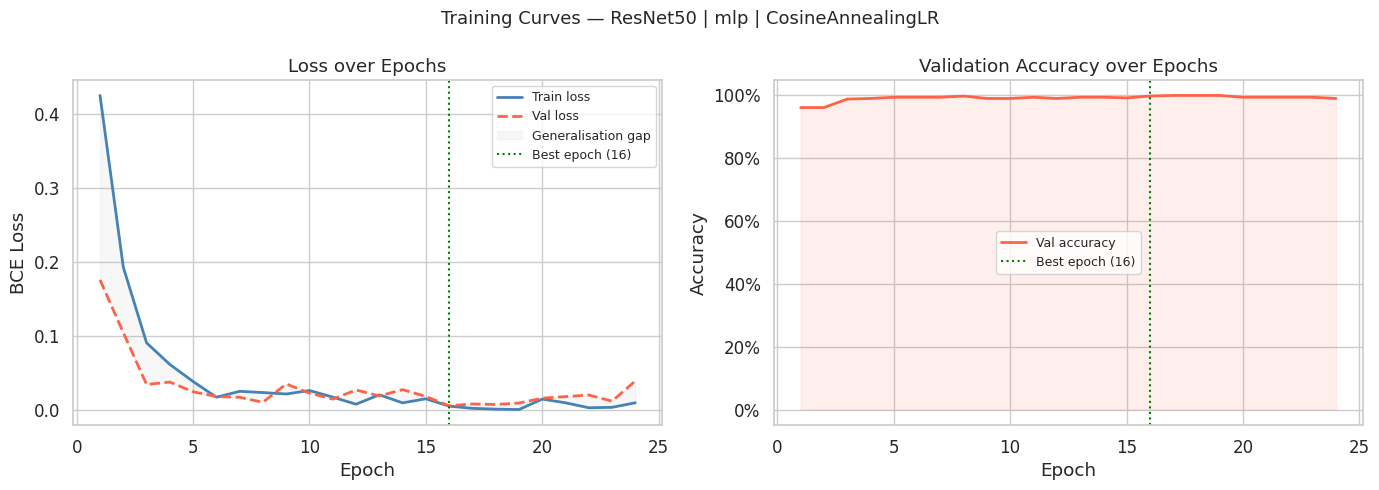

Epochs run : 24 (early stop @ patience=8)
Best epoch : 16
Best val loss : 0.0056
Best val acc : 0.9981


In [9]:
epochs_x = list(range(1, len(history["train_loss"]) + 1))
best_epoch = int(np.argmin(history["val_loss"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs_x, history["train_loss"], label="Train loss", lw=2, color="steelblue")
ax.plot(epochs_x, history["val_loss"], label="Val loss", lw=2, color="tomato", linestyle="--")
ax.fill_between(epochs_x, history["train_loss"], history["val_loss"],
                alpha=0.06, color="grey", label="Generalisation gap")
ax.axvline(best_epoch, color="green", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax.set_title("Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(epochs_x, history["val_acc"], label="Val accuracy", lw=2, color="tomato")
ax.fill_between(epochs_x, history["val_acc"], alpha=0.1, color="tomato")
ax.axvline(best_epoch, color="green", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax.set_title("Validation Accuracy over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(fontsize=9)

plt.suptitle(f"Training Curves — {MODEL_NAME} | {HEAD_TYPE} | {SCHEDULER_NAME}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Epochs run : {len(epochs_x)} (early stop @ patience={ES_PATIENCE})")
print(f"Best epoch : {best_epoch}")
print(f"Best val loss : {min(history['val_loss']):.4f}")
print(f"Best val acc : {max(history['val_acc']):.4f}")

## 8. Evaluation - Confusion Matrix

Evaluating test set:   0%|          | 0/17 [00:00<?, ?it/s]

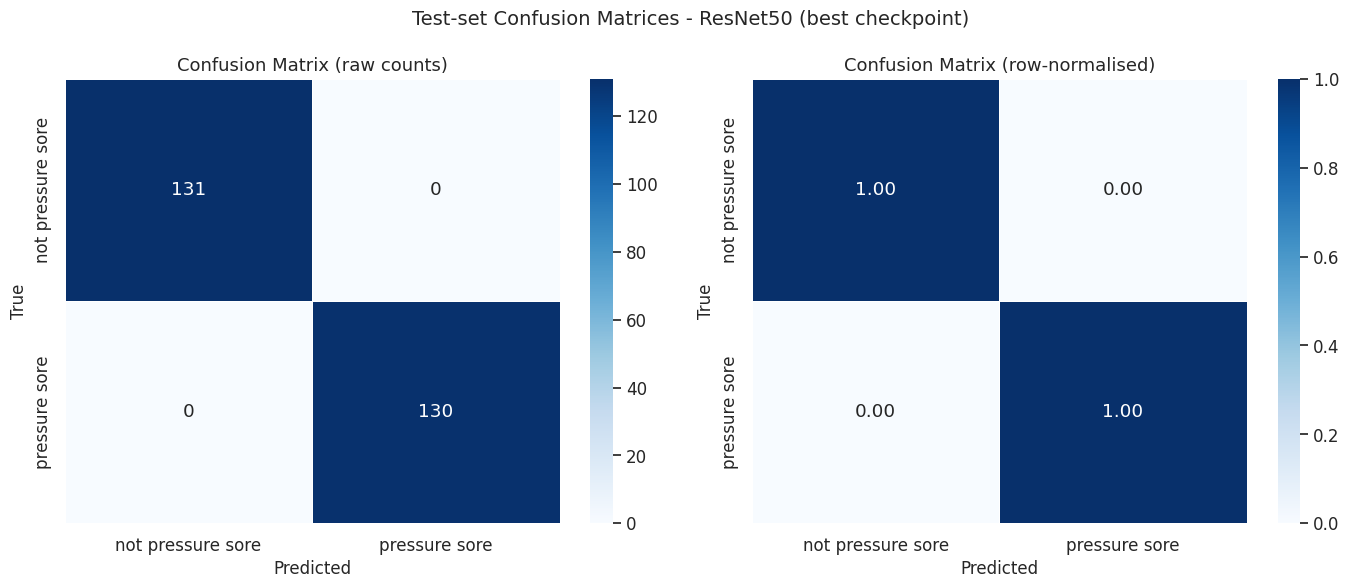

In [10]:
eval_model = build_model(MODEL_NAME, num_classes=1, dropout=DROPOUT, head_type=HEAD_TYPE)
eval_model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location="cpu"))
eval_model.eval().to(device)

raw_test_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, test_idx), val_test_transforms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count()
)

all_labels_test, all_probs_test = [], []
with torch.no_grad():
    for inputs, labels in tqdm(raw_test_loader, desc="Evaluating test set"):
        probs = torch.sigmoid(eval_model(inputs.to(device))).squeeze(1).cpu().numpy()
        all_probs_test.extend(probs.tolist())
        all_labels_test.extend(labels.numpy().tolist())

all_probs_test = np.array(all_probs_test)
all_labels_test = np.array(all_labels_test)
all_preds_test = (all_probs_test >= BINARY_THRESHOLD).astype(int)

cm_raw  = confusion_matrix(all_labels_test, all_preds_test)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title, fmt in zip(
    axes,
    [cm_raw, cm_norm],
    ["Confusion Matrix (raw counts)", "Confusion Matrix (row-normalised)"],
    ["d", ".2f"]
):
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13)

plt.suptitle(f"Test-set Confusion Matrices - {MODEL_NAME} (best checkpoint)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluation - Full Classification Report

In [11]:
print("=" * 55)
print("CLASSIFICATION REPORT — TEST SET")
print("=" * 55)
print(classification_report(all_labels_test, all_preds_test,
                             target_names=class_names, digits=4))

summary = {
    "Accuracy":  accuracy_score(all_labels_test, all_preds_test),
    "Macro Precision": precision_score(all_labels_test, all_preds_test, average="macro"),
    "Macro Recall": recall_score(all_labels_test, all_preds_test, average="macro"),
    "Macro F1": f1_score(all_labels_test, all_preds_test, average="macro"),
    "Weighted F1": f1_score(all_labels_test, all_preds_test, average="weighted"),
}
df_summary = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
df_summary["Value"] = df_summary["Value"].map("{:.4f}".format)
display(df_summary.set_index("Metric"))
df_summary.to_csv(f"{OUTPUT_DIR}/metrics_summary.csv", index=False)

CLASSIFICATION REPORT — TEST SET
                   precision    recall  f1-score   support

not pressure sore     1.0000    1.0000    1.0000       131
    pressure sore     1.0000    1.0000    1.0000       130

         accuracy                         1.0000       261
        macro avg     1.0000    1.0000    1.0000       261
     weighted avg     1.0000    1.0000    1.0000       261



,Value
Metric,
Accuracy,1.0000
Macro Precision,1.0000
Macro Recall,1.0000
Macro F1,1.0000
Weighted F1,1.0000


## 10. Evaluation - ROC Curve & Curve & AUC with Youden Threshold

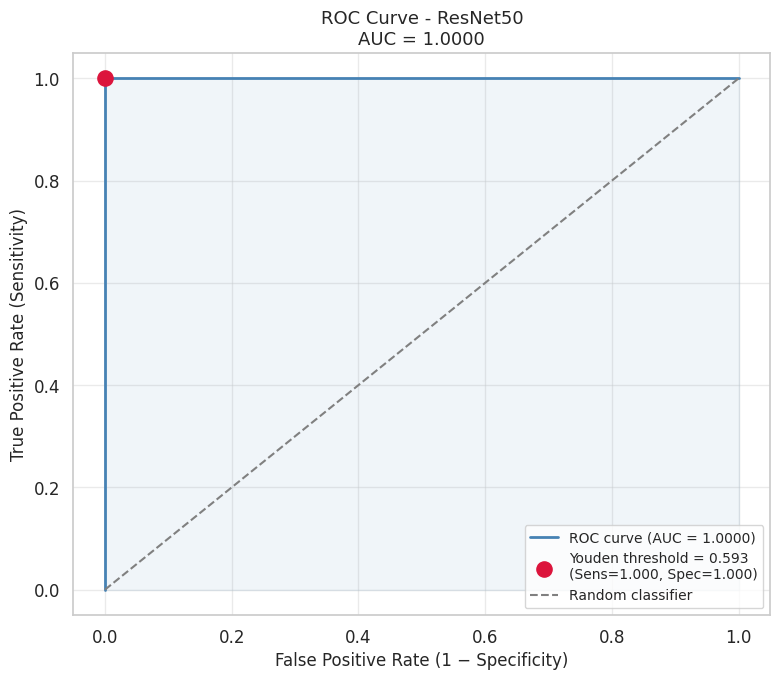

AUC-ROC : 1.0000
Youden threshold: 0.5934

At Youden threshold (0.593):
Accuracy : 1.0000
Macro F1 : 1.0000
Recall : 1.0000
Precision : 1.0000


In [12]:
pos_class_idx = full_dataset.class_to_idx.get(
    next((c for c in class_names if "pressure" in c.lower() and "no" not in c.lower()), class_names[1])
)
pos_probs = all_probs_test if pos_class_idx == 1 else (1 - all_probs_test)
binary_labels = (all_labels_test == pos_class_idx).astype(int)

fpr, tpr, thresholds = roc_curve(binary_labels, pos_probs)
auc_val = roc_auc_score(binary_labels, pos_probs)

j_scores = tpr - fpr
youden_idx = int(np.argmax(j_scores))
youden_thresh = float(thresholds[youden_idx])

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"ROC curve (AUC = {auc_val:.4f})")
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.scatter(
    fpr[youden_idx], tpr[youden_idx], s=120, color="crimson", zorder=5,
    label=f"Youden threshold = {youden_thresh:.3f}\n(Sens={tpr[youden_idx]:.3f}, Spec={1-fpr[youden_idx]:.3f})"
)
ax.plot([0,1],[0,1], "--", color="grey", lw=1.5, label="Random classifier")
ax.set_xlabel("False Positive Rate (1 − Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title(f"ROC Curve - {MODEL_NAME}\nAUC = {auc_val:.4f}", fontsize=13)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC-ROC : {auc_val:.4f}")
print(f"Youden threshold: {youden_thresh:.4f}")

preds_youden = (pos_probs >= youden_thresh).astype(int)
print(f"\nAt Youden threshold ({youden_thresh:.3f}):")
print(f"Accuracy : {accuracy_score(binary_labels, preds_youden):.4f}")
print(f"Macro F1 : {f1_score(binary_labels, preds_youden, average='macro'):.4f}")
print(f"Recall : {recall_score(binary_labels, preds_youden):.4f}")
print(f"Precision : {precision_score(binary_labels, preds_youden):.4f}")

# 11. Evaluation - Threshold Sensitivity Analysis


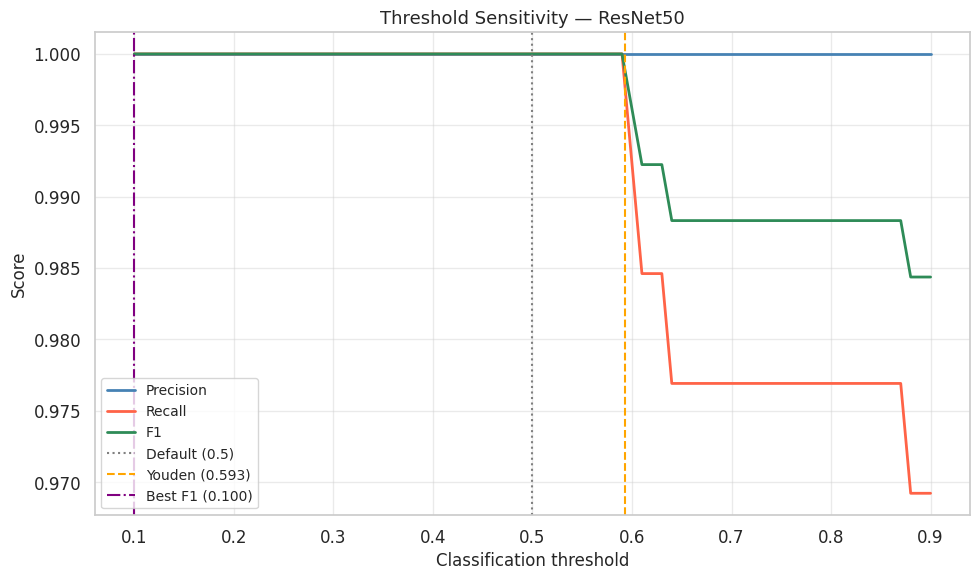

Default threshold (0.5)  F1 : 1.0000
Best F1 threshold : 0.10 → F1 = 1.0000
Youden threshold : 0.59


In [13]:
thresh_range = np.linspace(0.1, 0.9, 81)
precisions, recalls, f1s = [], [], []

for t in thresh_range:
    preds_t = (pos_probs >= t).astype(int)
    precisions.append(precision_score(binary_labels, preds_t, zero_division=0))
    recalls.append(recall_score(binary_labels, preds_t, zero_division=0))
    f1s.append(f1_score(binary_labels, preds_t, zero_division=0))

best_f1_idx = int(np.argmax(f1s))
best_f1_thresh = float(thresh_range[best_f1_idx])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range, precisions, label="Precision", lw=2, color="steelblue")
ax.plot(thresh_range, recalls, label="Recall", lw=2, color="tomato")
ax.plot(thresh_range, f1s, label="F1", lw=2, color="seagreen")
ax.axvline(BINARY_THRESHOLD, color="grey", linestyle=":", lw=1.5, label=f"Default ({BINARY_THRESHOLD})")
ax.axvline(youden_thresh, color="orange", linestyle="--", lw=1.5, label=f"Youden ({youden_thresh:.3f})")
ax.axvline(best_f1_thresh, color="purple", linestyle="-.", lw=1.5, label=f"Best F1 ({best_f1_thresh:.3f})")
ax.set_xlabel("Classification threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"Threshold Sensitivity — {MODEL_NAME}", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

default_f1 = f1s[int(np.argmin(np.abs(thresh_range - 0.5)))]
print(f"Default threshold (0.5)  F1 : {default_f1:.4f}")
print(f"Best F1 threshold : {best_f1_thresh:.2f} → F1 = {f1s[best_f1_idx]:.4f}")
print(f"Youden threshold : {youden_thresh:.2f}")

## 12. Model Export & Summary

In [15]:
final_path = f"{OUTPUT_DIR}/final_{MODEL_NAME}_{HEAD_TYPE}_{SCHEDULER_NAME}.pth"
torch.save(accelerator.unwrap_model(model).state_dict(), final_path)

print("=" * 55)
print("TRAINING & EVALUATION SUMMARY")
print("=" * 55)
print(f"Model : {MODEL_NAME}")
print(f"Head : {HEAD_TYPE} | Dropout: {DROPOUT:.4f}")
print(f"Scheduler : {SCHEDULER_NAME}")
print(f"Epochs run : {len(history['train_loss'])} / {NUM_EPOCHS}")
print(f"Best epoch : {best_epoch} (val loss {min(history['val_loss']):.4f})")
print(f"Early stop patience: {ES_PATIENCE}  |  delta: {ES_DELTA}")
print(f"Best weights : {BEST_WEIGHTS_PATH}")
print()
print(f"Test set size : {len(all_labels_test)}")
print(f"Threshold used : {BINARY_THRESHOLD}")
print()
print(f"Accuracy : {accuracy_score(all_labels_test, all_preds_test):.4f}")
print(f"Macro F1 : {f1_score(all_labels_test, all_preds_test, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(all_labels_test, all_preds_test, average='weighted'):.4f}")
print(f"AUC-ROC : {auc_val:.4f}")
print(f"Youden threshold : {youden_thresh:.4f}")
print(f"Best F1 threshold : {best_f1_thresh:.4f}")
print()
print("Saved artefacts:")
for fname in [
    "class_distribution.png", "training_curves.png",
    "confusion_matrices.png",  "roc_curve.png",
    "threshold_sensitivity.png", "sample_predictions.png",
    "metrics_summary.csv",
    Path(BEST_WEIGHTS_PATH).name,
    Path(final_path).name,
]:
    p = Path(OUTPUT_DIR) / fname
    print(f"{'✅' if p.exists() else '❌'}  {fname}")

TRAINING & EVALUATION SUMMARY
Model : ResNet50
Head : mlp | Dropout: 0.5840
Scheduler : CosineAnnealingLR
Epochs run : 24 / 50
Best epoch : 16 (val loss 0.0056)
Early stop patience: 8  |  delta: 0.0001
Best weights : /kaggle/working/best_ResNet50_mlp_CosineAnnealingLR.pth

Test set size : 261
Threshold used : 0.5

Accuracy : 1.0000
Macro F1 : 1.0000
Weighted F1 : 1.0000
AUC-ROC : 1.0000
Youden threshold : 0.5934
Best F1 threshold : 0.1000

Saved artefacts:
✅  class_distribution.png
✅  training_curves.png
✅  confusion_matrices.png
✅  roc_curve.png
✅  threshold_sensitivity.png
✅  sample_predictions.png
✅  metrics_summary.csv
✅  best_ResNet50_mlp_CosineAnnealingLR.pth
✅  final_ResNet50_mlp_CosineAnnealingLR.pth
